# Visualizing proteon features

The quickstart notebook showed how to *get* the features onto a PyG `Data`
object. This one shows what you can *see* once you have them: distance maps,
contact maps, SASA along the sequence, RSA painted onto the 3D structure,
Ramachandran with DSSP coloring, and energy decomposition across PDBs.

Most plots here are pure tensor math on `data.pos` / `data.residue_sasa` /
`data.dssp` / `data.phi/psi`. proteon-pyg gives you the substrate; the rest
is a short notebook.

Two structures throughout:
- **1crn** (crambin): 46 residues, single chain, all amino acids. The
  clean-narrative case.
- **1ake** (adenylate kinase): 808 residues split into protein + waters
  + ligand. The "what happens with non-AA residues" case.


In [1]:
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

import proteon_pyg
from proteon_pyg import DSSP_CLASSES, decode_dssp

PDB_DIR = Path("/scratch/TMAlign/proteon/test-pdbs")

# Load both at residue granularity, all features on.
crn = proteon_pyg.proteon_pyg_data(
    PDB_DIR / "1crn.pdb", hbond_count=True, dihedrals=True
)
ake = proteon_pyg.proteon_pyg_data(
    PDB_DIR / "1ake.pdb", hbond_count=True, dihedrals=True
)
print(f"1crn: {crn.pos.shape[0]} residues  ({int(crn.is_amino_acid.sum())} AA)")
print(f"1ake: {ake.pos.shape[0]} residues  ({int(ake.is_amino_acid.sum())} AA, "
      f"{int((~ake.is_amino_acid).sum())} non-AA)")

/scratch/TMAlign/proteon/.venv/lib/python3.12/site-packages/torch/__config__.py:9: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12050). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._show_config()


1crn: 46 residues  (46 AA)
1ake: 808 residues  (428 AA, 380 non-AA)


## 1. Distance map

`data.pos` holds CA coordinates per residue. A pairwise distance matrix is
one `torch.cdist` call:


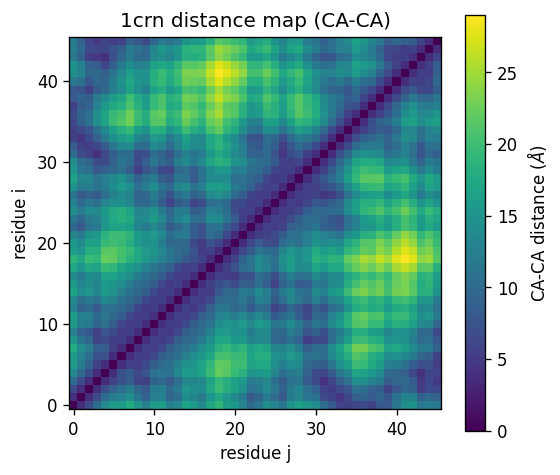

In [5]:
def distance_map(data):
    return torch.cdist(data.pos, data.pos)

dmap_crn = distance_map(crn)

fig, ax = plt.subplots(figsize=(5, 4.5), dpi=120)
im = ax.imshow(dmap_crn.numpy(), cmap="viridis", origin="lower")
fig.colorbar(im, ax=ax, label=r"CA-CA distance ($\AA$)")
ax.set_xlabel("residue j")
ax.set_ylabel("residue i")
ax.set_title("1crn distance map (CA-CA)")
plt.show()


## 2. Contact map

A contact map is just a thresholded distance map. 8 Å is a standard cutoff
for residue-residue contacts in fold prediction.


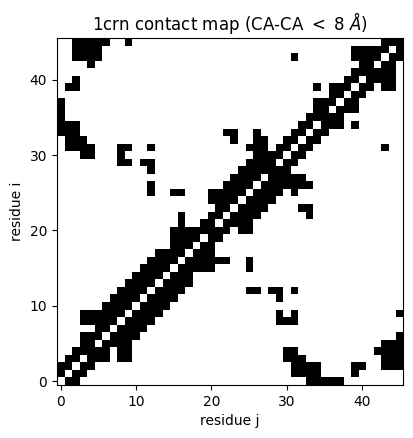

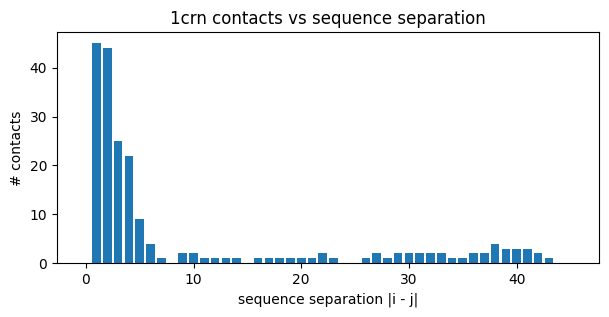

In [6]:
def contact_map(data, cutoff=8.0):
    d = distance_map(data)
    return (d < cutoff) & (d > 0)  # exclude self-contacts

cmap_crn = contact_map(crn, cutoff=8.0)

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.imshow(cmap_crn.numpy(), cmap="Greys", origin="lower")
ax.set_xlabel("residue j")
ax.set_ylabel("residue i")
ax.set_title(r"1crn contact map (CA-CA $<$ 8 $\AA$)")
plt.show()

# Sequence-separation density: how often does residue i contact i+k?
sep_density = np.zeros(crn.pos.shape[0])
n_pairs = cmap_crn.numpy().astype(int)
for k in range(1, crn.pos.shape[0]):
    sep_density[k] = np.diag(n_pairs, k=k).sum()

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(np.arange(len(sep_density)), sep_density)
ax.set_xlabel("sequence separation |i - j|")
ax.set_ylabel("# contacts")
ax.set_title("1crn contacts vs sequence separation")
plt.show()


## 3. SASA along the sequence

`data.residue_sasa` is one number per residue. Plotting it as a function of
residue index gives you a clean view of where the surface and core are.
The DSSP secondary-structure annotation goes nicely above as a strip.


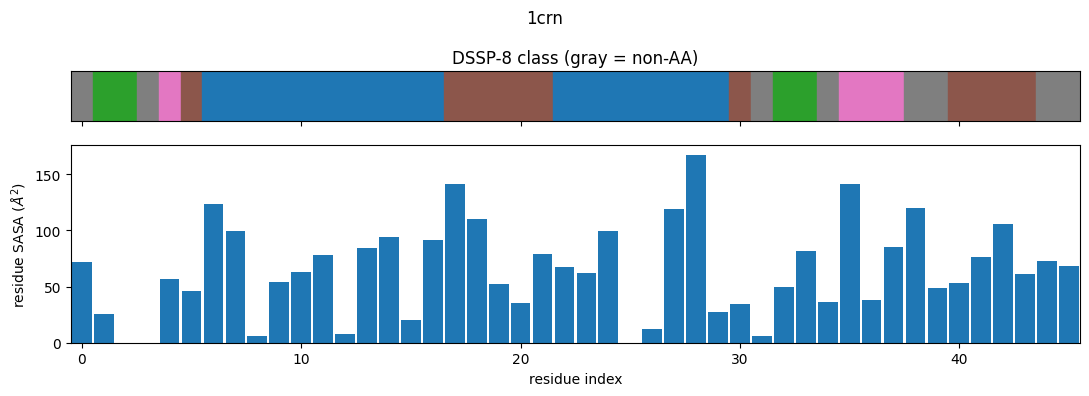

In [7]:
def plot_sasa_strip(data, title):
    n = data.pos.shape[0]
    fig, axes = plt.subplots(2, 1, figsize=(11, 4),
                             gridspec_kw={"height_ratios": [1, 4]},
                             sharex=True)
    # Top strip: DSSP class as colored bar
    cmap = plt.get_cmap("tab10")
    dssp = data.dssp.numpy()
    for i, c in enumerate(dssp):
        color = cmap(int(c) % 10) if c >= 0 else "0.85"
        axes[0].axvspan(i - 0.5, i + 0.5, color=color)
    axes[0].set_yticks([])
    axes[0].set_xlim(-0.5, n - 0.5)
    axes[0].set_title("DSSP-8 class (gray = non-AA)")
    # Bottom: SASA bars
    axes[1].bar(np.arange(n), data.residue_sasa.numpy(), color="C0", width=0.9)
    axes[1].set_xlabel("residue index")
    axes[1].set_ylabel(r"residue SASA ($\AA^2$)")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

plot_sasa_strip(crn, "1crn")

## 4. RSA painted onto the 3D structure

`data.rsa` is each residue's relative SASA. Coloring CA positions by RSA
shows you the surface (high RSA) vs the core (low RSA) at a glance.


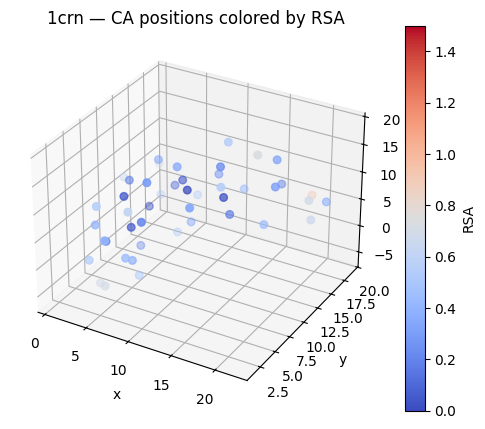

In [8]:
def plot_rsa_3d(data, title):
    pos = data.pos.numpy()
    rsa = data.rsa.numpy()
    # Replace NaN with 0 just for the colormap; mark them in gray.
    rsa_for_color = np.where(np.isnan(rsa), 0.0, rsa)
    is_known = ~np.isnan(rsa)

    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(
        pos[is_known, 0], pos[is_known, 1], pos[is_known, 2],
        c=rsa_for_color[is_known], cmap="coolwarm",
        vmin=0.0, vmax=1.5, s=30,
    )
    if (~is_known).any():
        ax.scatter(
            pos[~is_known, 0], pos[~is_known, 1], pos[~is_known, 2],
            c="0.6", s=15, marker="x", label="non-standard residues",
        )
        ax.legend()
    fig.colorbar(sc, ax=ax, label="RSA")
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.set_title(title)
    plt.show()

plot_rsa_3d(crn, "1crn — CA positions colored by RSA")

## 5. Ramachandran scatter colored by DSSP class

The classic structural-biology plot: phi vs psi, one point per residue.
Coloring by DSSP class shows that helix and sheet residues live in
specific regions of the plot — that's the floor any geometric-DL model
trained on these features needs to recover.


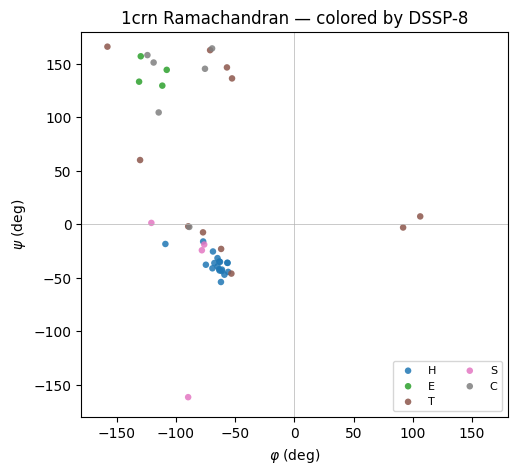

In [9]:
def plot_ramachandran(data, title):
    phi = data.phi.numpy()
    psi = data.psi.numpy()
    dssp = data.dssp.numpy()
    mask = ~(np.isnan(phi) | np.isnan(psi))
    phi_v, psi_v, dssp_v = phi[mask], psi[mask], dssp[mask]

    fig, ax = plt.subplots(figsize=(5.5, 5))
    cmap = plt.get_cmap("tab10")
    for cls_idx, cls_name in enumerate(DSSP_CLASSES):
        sel = dssp_v == cls_idx
        if not sel.any():
            continue
        ax.scatter(
            phi_v[sel], psi_v[sel], s=22, color=cmap(cls_idx),
            label=cls_name, alpha=0.85, edgecolors="none",
        )
    # Non-AA / unassigned in gray
    sel = dssp_v < 0
    if sel.any():
        ax.scatter(phi_v[sel], psi_v[sel], s=18, color="0.5", label="non-AA")
    ax.set_xlim(-180, 180); ax.set_ylim(-180, 180)
    ax.set_xlabel(r"$\varphi$ (deg)"); ax.set_ylabel(r"$\psi$ (deg)")
    ax.axhline(0, color="0.7", linewidth=0.5)
    ax.axvline(0, color="0.7", linewidth=0.5)
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=8, ncol=2)
    plt.show()

plot_ramachandran(crn, "1crn Ramachandran — colored by DSSP-8")

## 6. Energy decomposition

`proteon_energy_<component>` lands as 0-dim tensors. A horizontal stacked
bar chart across a few PDBs shows where each one's energy comes from.


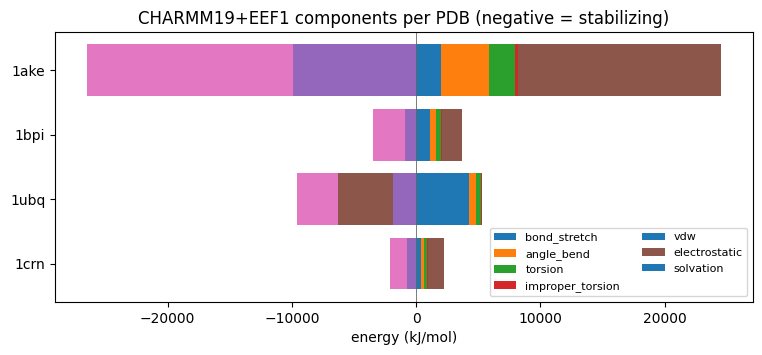

Totals (kJ/mol):
  1crn:      93.19
  1ubq:   -4279.72
  1bpi:     243.40
  1ake:   -1985.57


In [10]:
COMPONENTS = ["bond_stretch", "angle_bend", "torsion", "improper_torsion",
              "vdw", "electrostatic", "solvation"]

def energy_components(data):
    return np.array([float(getattr(data, f"proteon_energy_{c}").item())
                     for c in COMPONENTS])

# Load a few more for a wider comparison.
ubq = proteon_pyg.proteon_pyg_data(PDB_DIR / "1ubq.pdb")
bpi = proteon_pyg.proteon_pyg_data(PDB_DIR / "1bpi.pdb")
labels = ["1crn", "1ubq", "1bpi", "1ake"]
matrix = np.stack([energy_components(d) for d in (crn, ubq, bpi, ake)])

fig, ax = plt.subplots(figsize=(9, 3.5))
y = np.arange(len(labels))
left_pos = np.zeros_like(y, dtype=float)
left_neg = np.zeros_like(y, dtype=float)
cmap = plt.get_cmap("tab10")
for i, comp in enumerate(COMPONENTS):
    vals = matrix[:, i]
    pos_mask = vals >= 0
    neg_mask = ~pos_mask
    ax.barh(y[pos_mask], vals[pos_mask], left=left_pos[pos_mask],
            color=cmap(i), label=comp)
    ax.barh(y[neg_mask], vals[neg_mask], left=left_neg[neg_mask], color=cmap(i))
    left_pos[pos_mask] += vals[pos_mask]
    left_neg[neg_mask] += vals[neg_mask]
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xlabel("energy (kJ/mol)")
ax.axvline(0, color="0.4", linewidth=0.6)
ax.set_title("CHARMM19+EEF1 components per PDB (negative = stabilizing)")
ax.legend(loc="lower right", fontsize=8, ncol=2)
plt.show()

print("Totals (kJ/mol):")
for d, name in zip((crn, ubq, bpi, ake), labels):
    print(f"  {name}: {float(d.proteon_energy_total.item()):>10.2f}")

## 7. The HETATM story (1ake)

1ake has waters and a ligand alongside the protein, so its `data` carries
non-AA residues. `data.is_amino_acid` is the mask, and `data.dssp` is `-1`
at non-AA positions. The same plots still work — they just show extra
structure.


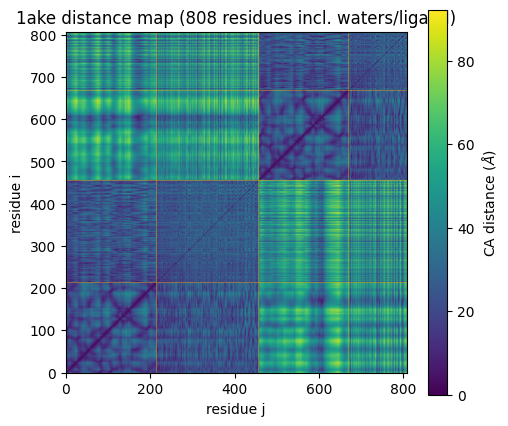

In [11]:
# Distance map: blocks of waters + ligand show up as extra rows/columns
dmap_ake = distance_map(ake)
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(dmap_ake.numpy(), cmap="viridis", origin="lower")
fig.colorbar(im, ax=ax, label=r"CA distance ($\AA$)")
ax.set_title(f"1ake distance map ({ake.pos.shape[0]} residues incl. waters/ligand)")
ax.set_xlabel("residue j"); ax.set_ylabel("residue i")

# Mark the AA / non-AA boundary
boundaries = np.where(np.diff(ake.is_amino_acid.numpy().astype(int)) != 0)[0]
for b in boundaries:
    ax.axhline(b + 0.5, color="orange", linewidth=0.5, alpha=0.6)
    ax.axvline(b + 0.5, color="orange", linewidth=0.5, alpha=0.6)
plt.show()


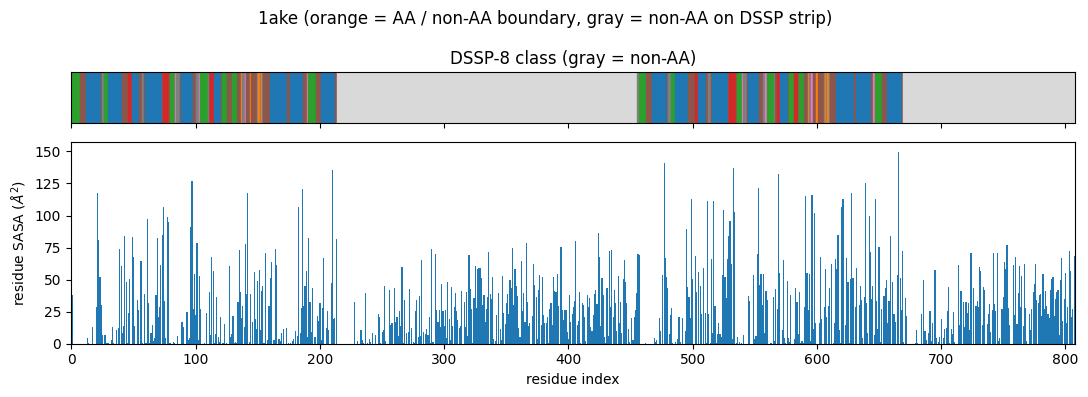

In [9]:
# SASA strip on 1ake: waters/ligand have well-defined SASA but no DSSP
plot_sasa_strip(ake, "1ake (orange = AA / non-AA boundary, gray = non-AA on DSSP strip)")


## What's next

- **Atom-level visualizations**: rebuild any of these with
  `granularity="atom"`. Atom-level Data adds `data.charge`, `data.is_backbone`,
  `data.atom_sasa`, `data.residue_index` — colors and groupings get richer.
- **Real datasets**: swap `proteon_pyg.proteon_pyg_data_batch(paths, ...)` in
  for a list of PDBs and the same plots roll up across the whole set.
- **Edge construction**: `data.pos` is enough to build any edge index you
  want (k-NN, distance threshold, sequence neighbors). PyG's
  `torch_cluster.knn_graph(data.pos, k=8)` is one line away from a usable
  graph for a GNN.
